In [1]:
import sys,os
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# set this up to point to the libararies directory in ml-holodec
dirP_str = os.path.join(os.environ['HOME'], 
                    'PythonScripts',
                    'Optics')
if dirP_str not in sys.path:
    sys.path.append(dirP_str)

In [3]:
import MieLibrary as mie

In [4]:
wavelen = 532e-9
index_refrac = 1.5

In [144]:
r_arr = np.logspace(-10,-5,1000)
ang_arr = np.linspace(0,500e-6,100)
dang=np.diff(ang_arr)

In [268]:
solid_angle = 2*np.pi*np.trapz(np.sin(ang_arr),ang_arr)

In [269]:
r_mat, ang_mat = np.meshgrid(r_arr,ang_arr)

In [278]:
sig_pi = np.zeros(r_arr.size)
sig_e = np.zeros(r_arr.size)
k_num = 2*np.pi/wavelen

for r_idx,r_val in enumerate(r_arr):
    x_val = 2*np.pi*r_val/wavelen
    Fmat = mie.Mie_PhaseMatrix(index_refrac, x_val, np.pi+ang_arr)
    sig_pi[r_idx] = np.real(1/k_num**2*2*np.pi*np.trapz(Fmat[0,:]*np.sin(ang_arr),ang_arr))
    sig_e[r_idx] = np.real(mie.CrossSections(index_refrac,x_val)[0])*(np.pi*r_val**2)/2

In [260]:
test_ang_arr = np.linspace(0,180,1000)*np.pi/180
Fmat = mie.Mie_PhaseMatrix(index_refrac, x_val, test_ang_arr)

In [263]:
1/k_num**2*np.pi*np.trapz(Fmat[0,:]*np.sin(test_ang_arr),test_ang_arr)

(3.320505581987796e-10+0j)

In [266]:
np.real(mie.CrossSections(index_refrac,x_val))*(np.pi*r_val**2)/2

array([3.33069584e-10, 3.33069584e-10])

In [267]:
np.trapz(np.sin(test_ang_arr),test_ang_arr)

1.9999983517708522

/h/eol/mhayman/.local/lib/python3.7/site-packages/numpy/core/_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


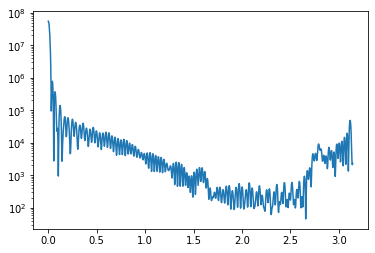

In [177]:
plt.figure()
plt.plot(test_ang_arr,Fmat[0,:])
plt.yscale('log')

In [168]:
r_val

1e-05

In [169]:
x_val

118.1049869770599

In [279]:
# mu_LN = np.log(1e-7)
sig_LN_arr = np.arange(0.1,1.5,0.1)
mu_LN_arr = np.arange(-18,-14,0.5)
# sig_LN = 0.5
sig_e_eff_lst = []
sig_pi_eff_lst = []
r_eff_lst = []
sig_LN_lst = []
mu_LN_lst = []
nd_lst = []

for sig_LN in sig_LN_arr:
    for mu_LN in mu_LN_arr:
        x = r_arr
        nd = 1/(x*sig_LN*np.sqrt(2*np.pi))*np.exp(-(np.log(x)-mu_LN)**2/(2*sig_LN**2))
        sig_e_eff = np.trapz(sig_e/2*nd,r_arr)
        sig_pi_eff = np.trapz(sig_pi*nd,r_arr)
        r_eff = np.trapz(r_arr**3*nd,r_arr)/np.trapz(r_arr**2*nd,r_arr)
        sig_e_eff_lst.append(sig_e_eff)
        sig_pi_eff_lst.append(sig_pi_eff)
        r_eff_lst.append(r_eff)
        sig_LN_lst.append(sig_LN)
        mu_LN_lst.append(mu_LN)
        nd_lst.append(nd)

In [280]:
np.trapz(nd_lst[10],r_arr)

1.000022135637969

Text(0, 0.5, 'backscatter coeff')

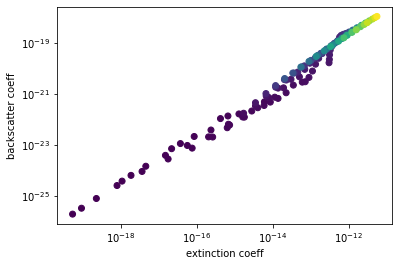

In [281]:
plt.figure()
# plt.plot(sig_e,sig_pi)
plt.scatter(sig_e_eff_lst,sig_pi_eff_lst,c=r_eff_lst)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('extinction coeff')
plt.ylabel('backscatter coeff')

In [274]:
nd_range_arr

array([1.00000000e+07, 1.04761575e+07, 1.09749877e+07, 1.14975700e+07,
       1.20450354e+07, 1.26185688e+07, 1.32194115e+07, 1.38488637e+07,
       1.45082878e+07, 1.51991108e+07, 1.59228279e+07, 1.66810054e+07,
       1.74752840e+07, 1.83073828e+07, 1.91791026e+07, 2.00923300e+07,
       2.10490414e+07, 2.20513074e+07, 2.31012970e+07, 2.42012826e+07,
       2.53536449e+07, 2.65608778e+07, 2.78255940e+07, 2.91505306e+07,
       3.05385551e+07, 3.19926714e+07, 3.35160265e+07, 3.51119173e+07,
       3.67837977e+07, 3.85352859e+07, 4.03701726e+07, 4.22924287e+07,
       4.43062146e+07, 4.64158883e+07, 4.86260158e+07, 5.09413801e+07,
       5.33669923e+07, 5.59081018e+07, 5.85702082e+07, 6.13590727e+07,
       6.42807312e+07, 6.73415066e+07, 7.05480231e+07, 7.39072203e+07,
       7.74263683e+07, 8.11130831e+07, 8.49753436e+07, 8.90215085e+07,
       9.32603347e+07, 9.77009957e+07, 1.02353102e+08, 1.07226722e+08,
       1.12332403e+08, 1.17681195e+08, 1.23284674e+08, 1.29154967e+08,
      

Text(0, 0.5, 'backscatter coeff')

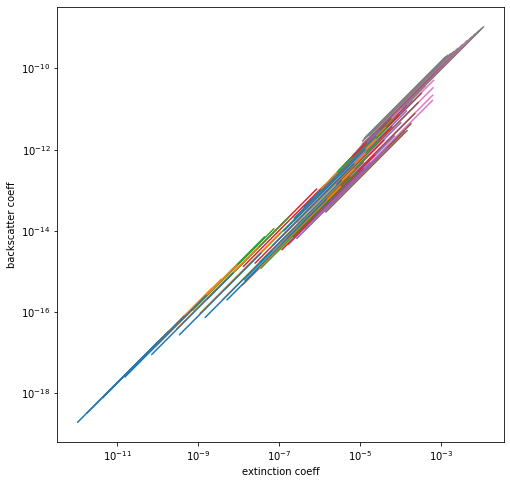

In [275]:
color_lst = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown']
nd_range_arr = np.logspace(1,3,100)*1e6

mu_area_e_arr = np.zeros((mu_LN_arr.size,sig_LN_arr.size,2))
mu_area_pi_arr = np.zeros((mu_LN_arr.size,sig_LN_arr.size,2))

# mu_area_e_lst = []
# mu_area_e_lst_lst = []
# mu_area_pi_lst = []
# mu_area_pi_lst_lst = []
mu_lst_idx = 0

fig,ax = plt.subplots(1,1,figsize=(8,8))
for idx in range(len(sig_e_eff_lst)):
    mu_idx = mu_LN_arr.tolist().index(mu_LN_lst[idx])
    sig_idx = sig_LN_arr.tolist().index(sig_LN_lst[idx])
    mu_area_e_arr[mu_idx,sig_idx,0] = sig_e_eff_lst[idx]*nd_range_arr[0]
    mu_area_e_arr[mu_idx,sig_idx,1] = sig_e_eff_lst[idx]*nd_range_arr[-1]
    mu_area_pi_arr[mu_idx,sig_idx,0] = sig_pi_eff_lst[idx]*nd_range_arr[0]
    mu_area_pi_arr[mu_idx,sig_idx,1] = sig_pi_eff_lst[idx]*nd_range_arr[-1]
#     if mu_idx != mu_lst_idx:
#         mu_area_e_lst_lst.append(np.array(mu_area_e_lst))
#         mu_area_e_lst = []
#         mu_area_pi_lst_lst.append(np.array(mu_area_pi_lst))
#         mu_area_pi_lst = []
    ax.plot(sig_e_eff_lst[idx]*nd_range_arr,sig_pi_eff_lst[idx]*nd_range_arr,color='C%d'%mu_idx)
#     mu_area_e_lst.append([sig_e_eff_lst[idx]*nd_range_arr[0],sig_e_eff_lst[idx]*nd_range_arr[-1]])
#     mu_area_pi_lst.append([sig_pi_eff_lst[idx]*nd_range_arr[0],sig_pi_eff_lst[idx]*nd_range_arr[-1]])
# plt.scatter(sig_e_eff_lst,sig_pi_eff_lst,c=r_eff_lst)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('extinction coeff')
ax.set_ylabel('backscatter coeff')

In [276]:
mu_area_e_arr.shape

(8, 14, 2)

Text(0, 0.5, 'backscatter coeff')

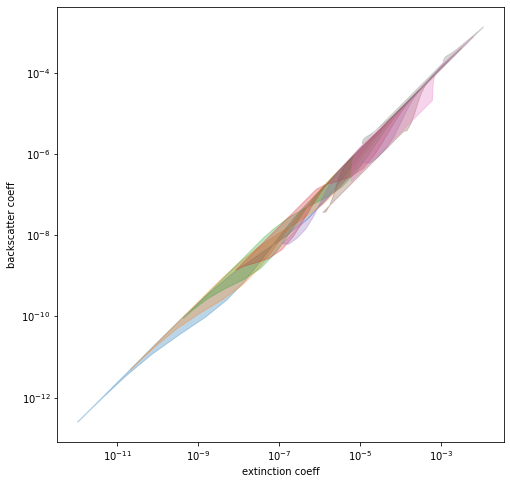

In [277]:
fig,ax = plt.subplots(1,1,figsize=(8,8))
for idx in range(mu_area_pi_arr.shape[0]):
    mu_area_sub_e_arr = mu_area_e_arr[idx]
    mu_area_sub_pi_arr = mu_area_pi_arr[idx]
    xf = np.concatenate([mu_area_sub_e_arr[:,0], mu_area_sub_e_arr[::-1,1]])
    yf = np.concatenate([mu_area_sub_pi_arr[:,0], mu_area_sub_pi_arr[::-1,1]])/solid_angle
#     yf = np.concatenate([xy[:, 1] + y_shift, xy_e[::-1, 1] + y_shift_e])
    ax.fill(xf, yf, color='C%d'%idx, alpha=0.3)
# plt.scatter(sig_e_eff_lst,sig_pi_eff_lst,c=r_eff_lst)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('extinction coeff')
plt.ylabel('backscatter coeff')

In [154]:
np.exp(mu_LN_arr)

array([1.52299797e-08, 4.13993772e-08, 1.12535175e-07, 3.05902321e-07])

In [155]:
np.trapz(nd,r_arr)

0.9936479372851045

In [156]:
mu_LN_lst

[-18,
 -17,
 -16,
 -15,
 -18,
 -17,
 -16,
 -15,
 -18,
 -17,
 -16,
 -15,
 -18,
 -17,
 -16,
 -15,
 -18,
 -17,
 -16,
 -15,
 -18,
 -17,
 -16,
 -15,
 -18,
 -17,
 -16,
 -15,
 -18,
 -17,
 -16,
 -15,
 -18,
 -17,
 -16,
 -15,
 -18,
 -17,
 -16,
 -15,
 -18,
 -17,
 -16,
 -15,
 -18,
 -17,
 -16,
 -15,
 -18,
 -17,
 -16,
 -15,
 -18,
 -17,
 -16,
 -15]

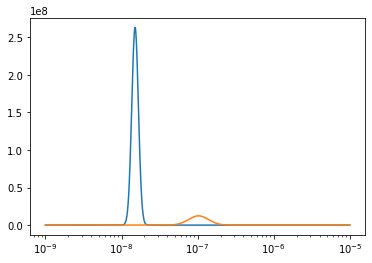

In [143]:
plt.figure()
plt.plot(r_arr,nd_lst[0])
plt.plot(r_arr,nd_lst[10])
plt.xscale('log')

In [43]:
sig_pi_eff

4.034890458705067e-20

In [45]:
sig_e_eff

0.7632948048537884

In [52]:
sig_e_eff_lst

[0.38974551851687905]

In [93]:
!ls /scr/sci/mhayman/SOCRATES/test_BM3D/plots/SOCRATESrf15

Hourly
